### Regression Algorithms
- House Price Prediction

In [1]:
# load, process and visualize
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# algorithms
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error

# save model
import joblib

In [2]:
data = pd.read_csv('../../data/house-price.csv')
df = data.copy()
df.head().T

,0,1,2,3,4
longitude,-122.0500,-118.300,-117.8100,-118.3600,-119.6700
latitude,37.3700,34.260,33.7800,33.8200,36.3300
housing_median_age,27.0000,43.000,27.0000,28.0000,19.0000
total_rooms,3885.0000,1510.000,3589.0000,67.0000,1241.0000
total_bedrooms,661.0000,310.000,507.0000,15.0000,244.0000
population,1537.0000,809.000,1484.0000,49.0000,850.0000
households,606.0000,277.000,495.0000,11.0000,237.0000
median_income,6.6085,3.599,5.7934,6.1359,2.9375
median_house_value,344700.0000,176500.000,270500.0000,330000.0000,81700.0000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


- 1. Data Preprocessing

In [5]:
print("Missing values:", df.isna().sum())
print("Shape:", df.shape)

Missing values: longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64
Shape: (3000, 9)


In [6]:
print('Duplicate values:', df.duplicated().sum())

# Splitting columns
df_num = df.select_dtypes(include='number')
df_cat = df.select_dtypes(exclude='number')

Duplicate values: 0


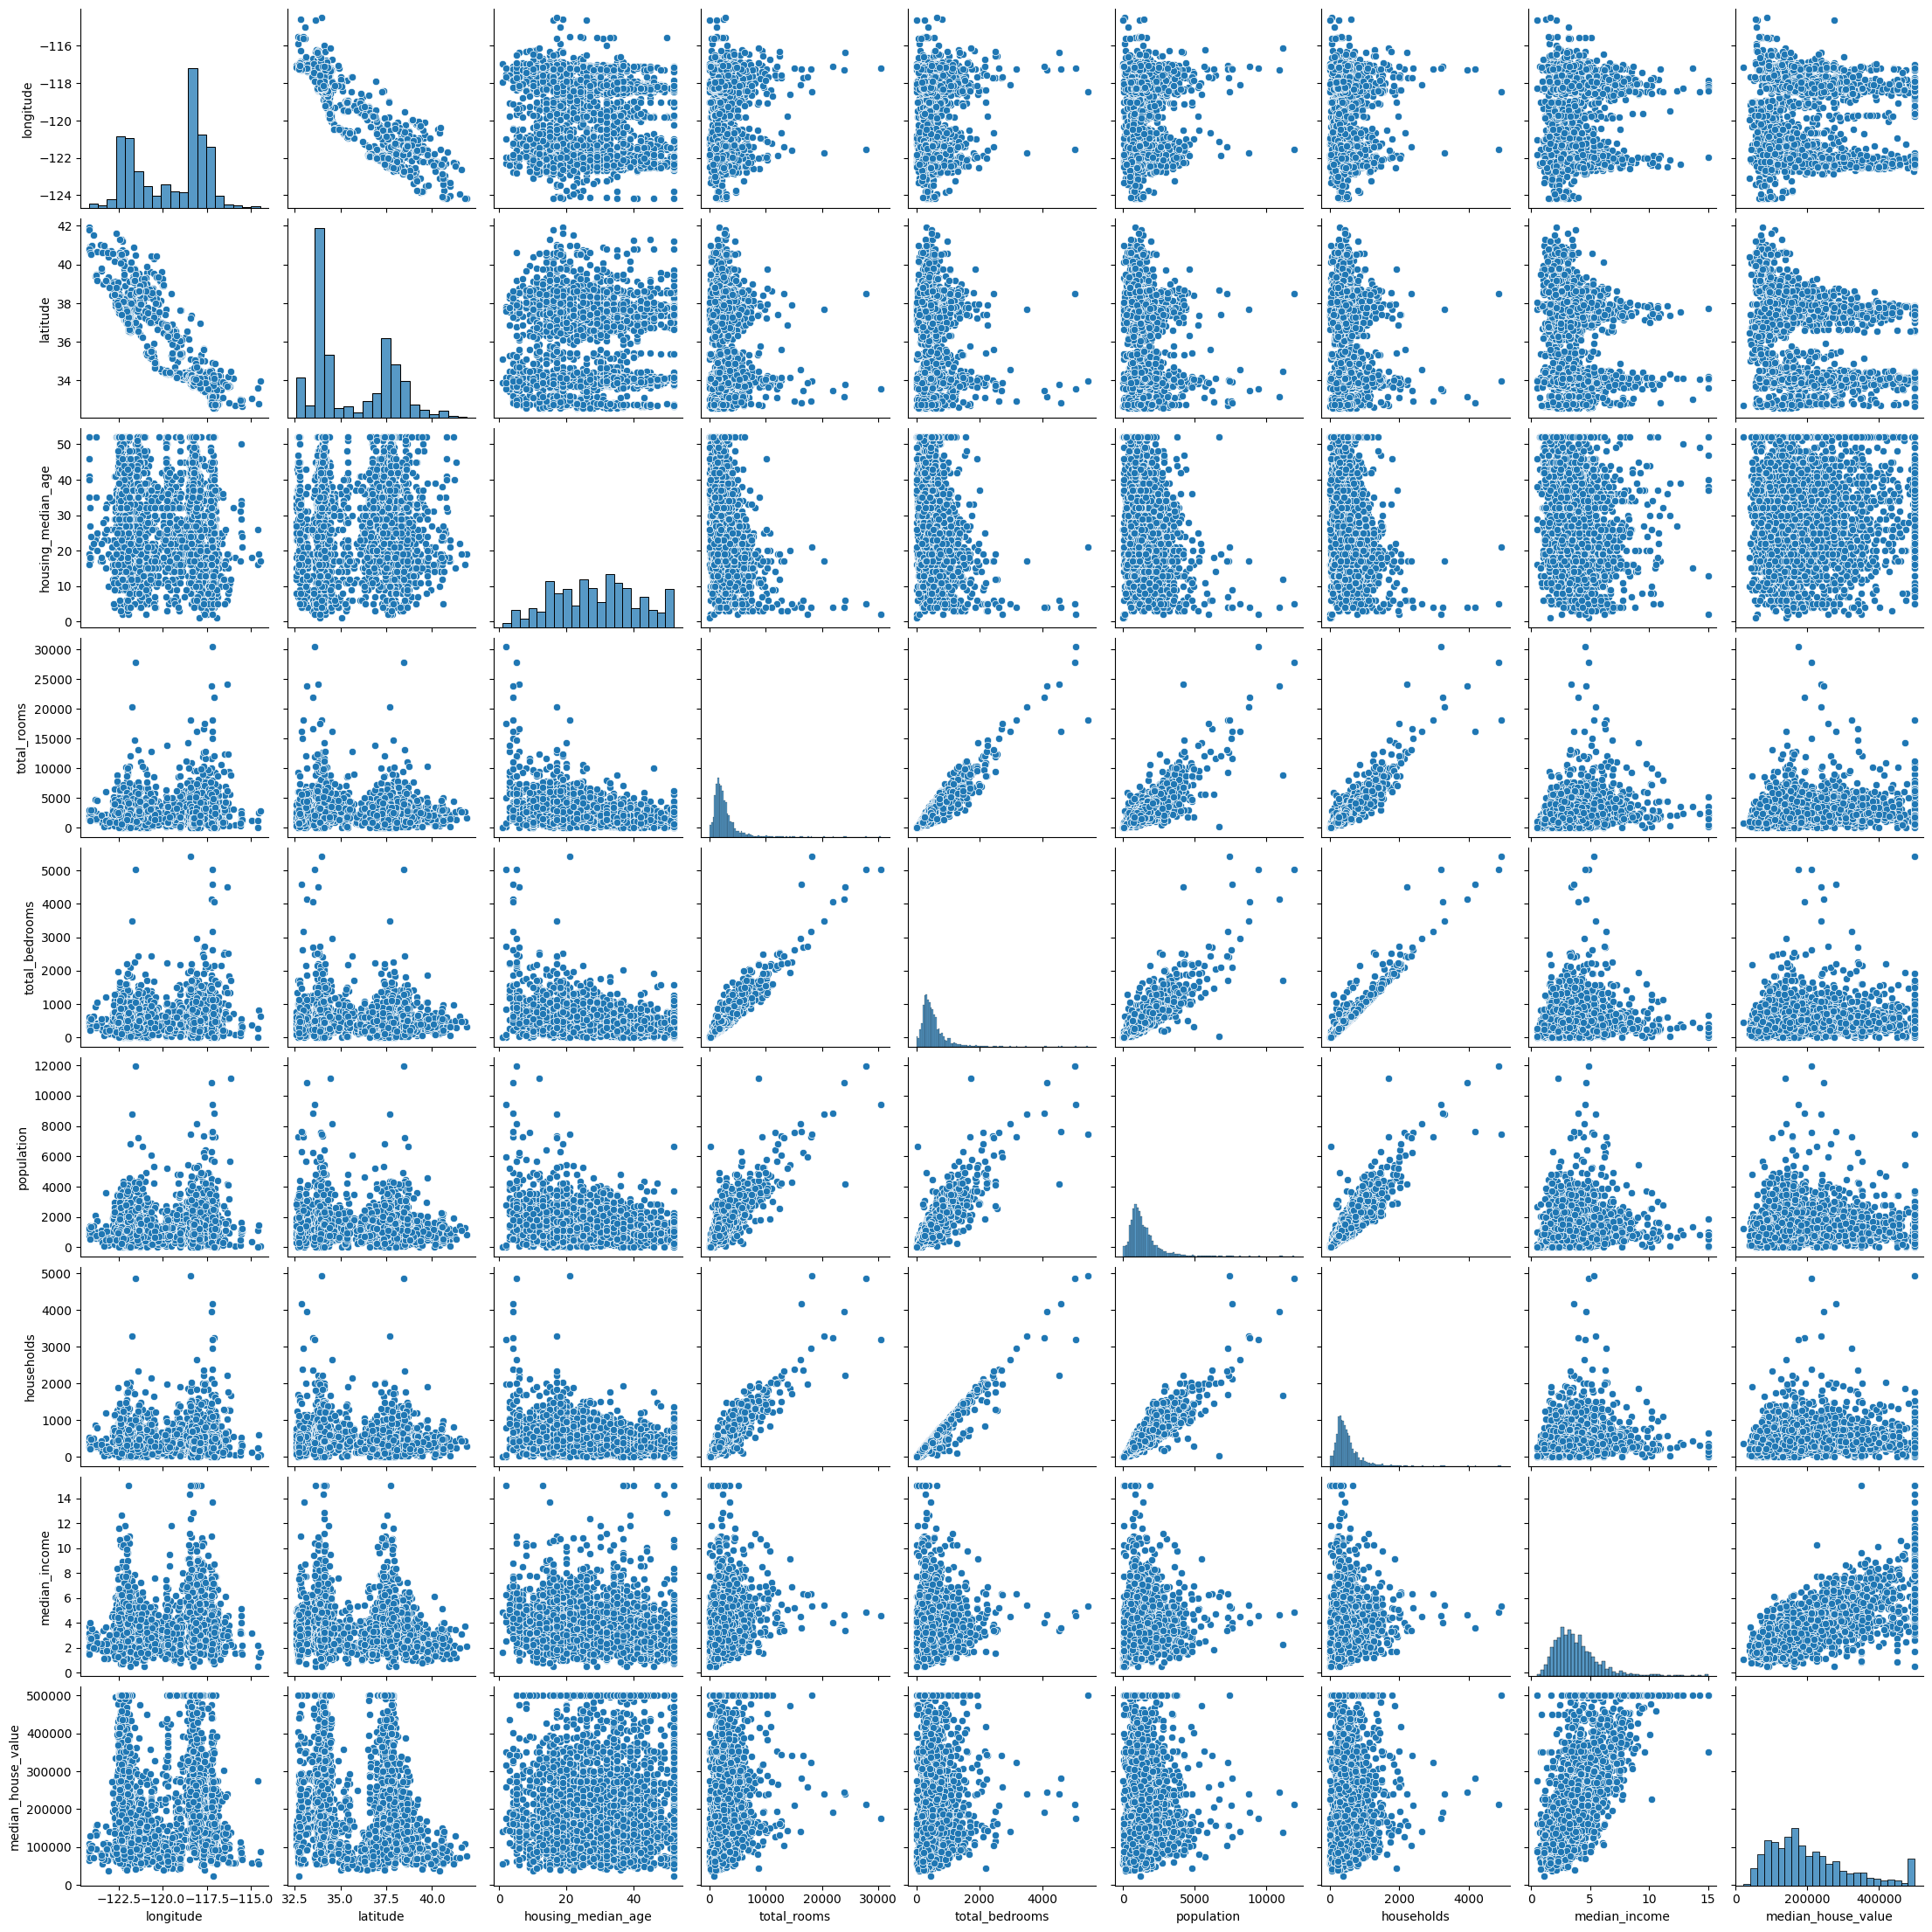

In [7]:
# pair plot of numerical columns
sns.pairplot(df_num)
plt.show()

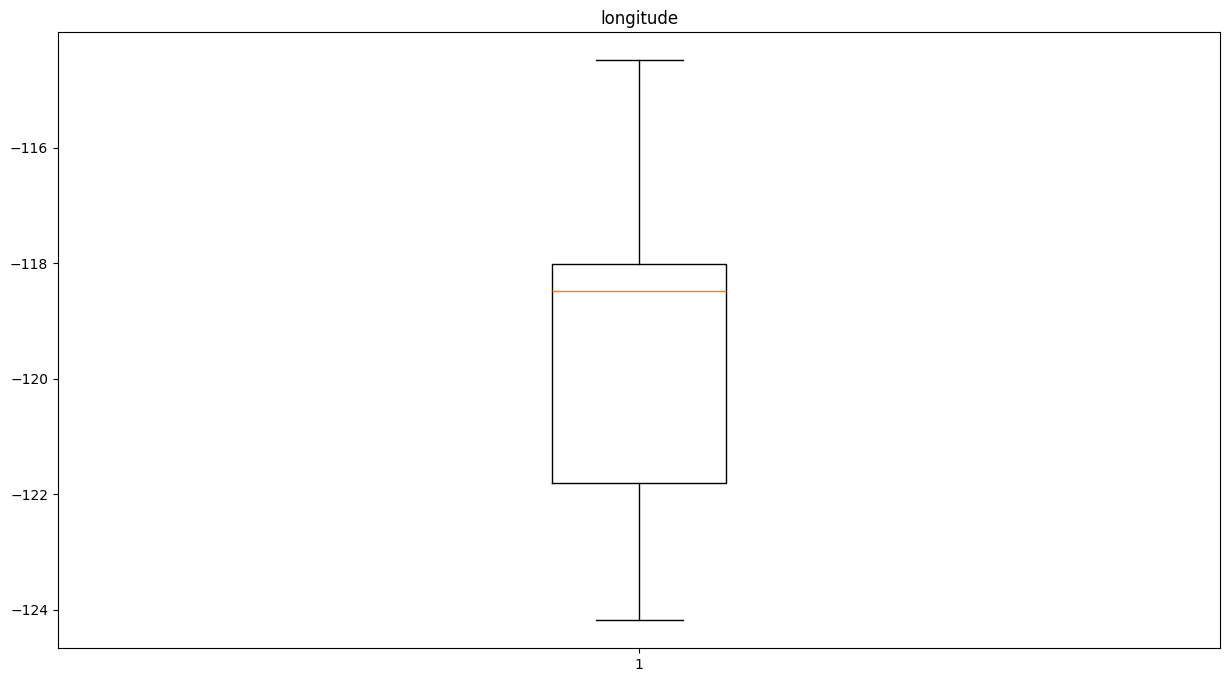

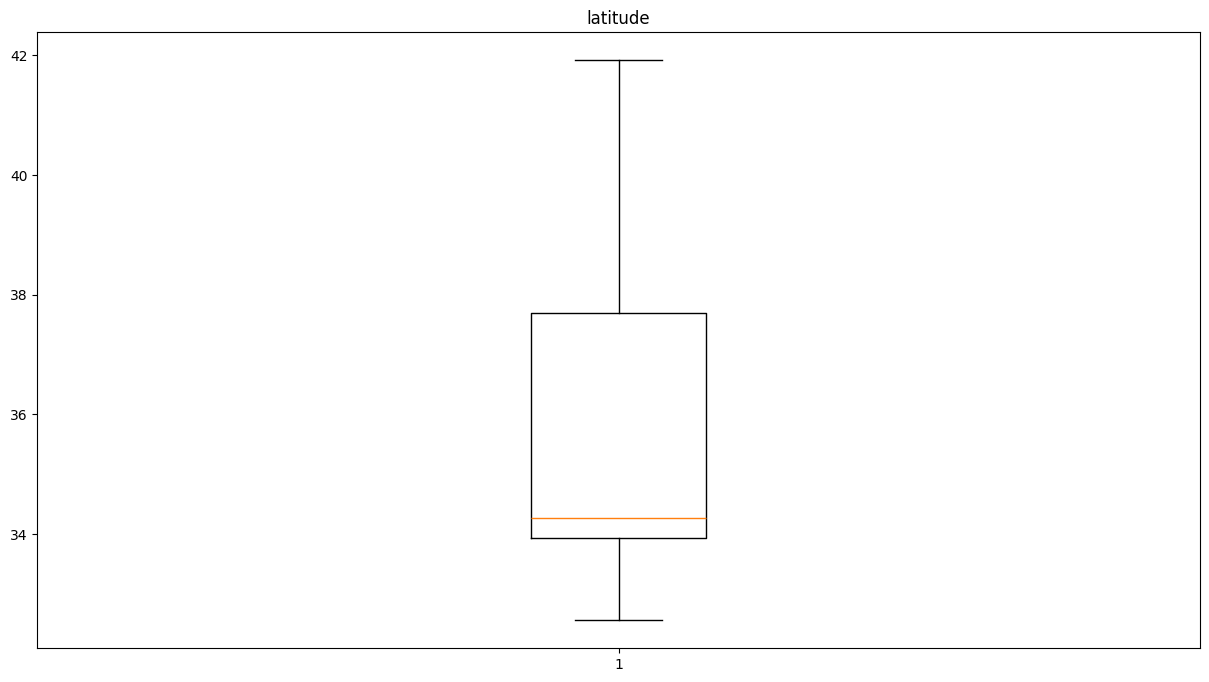

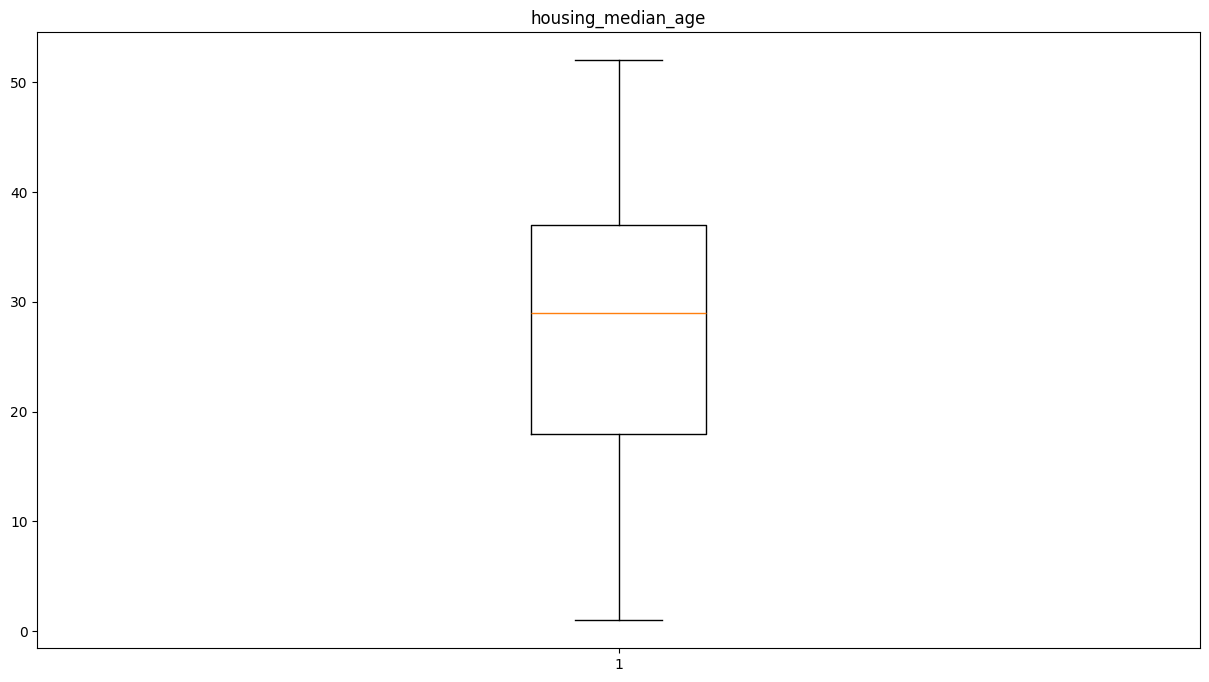

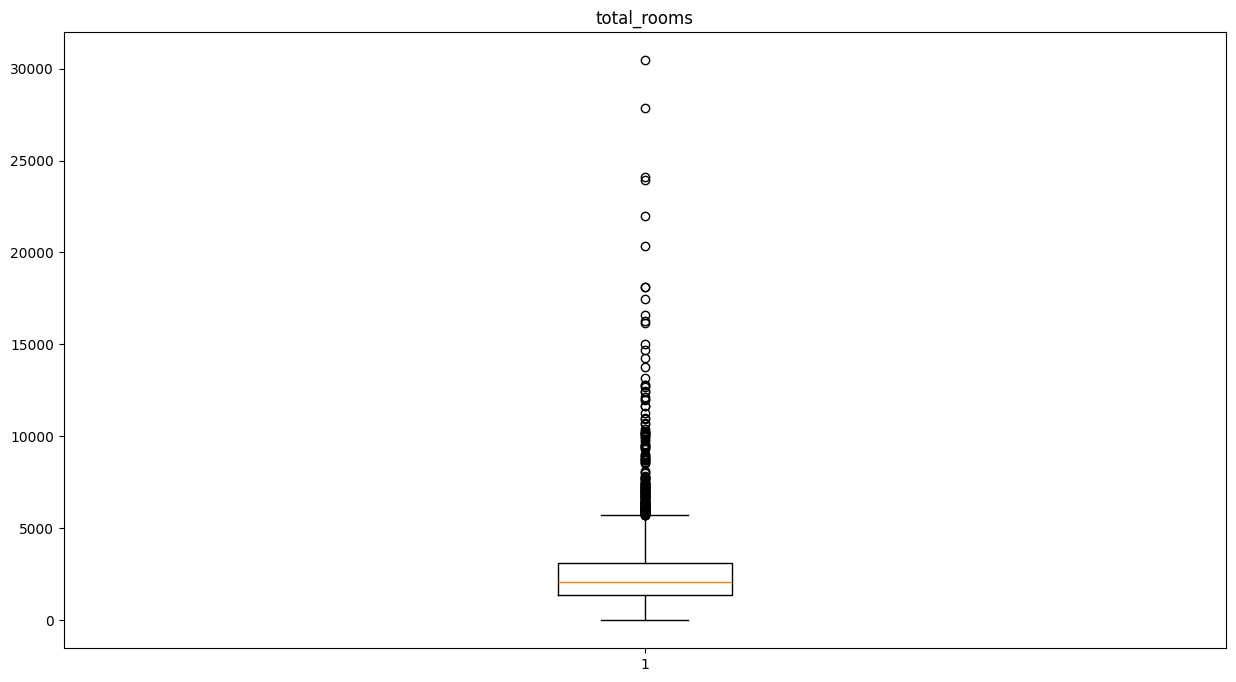

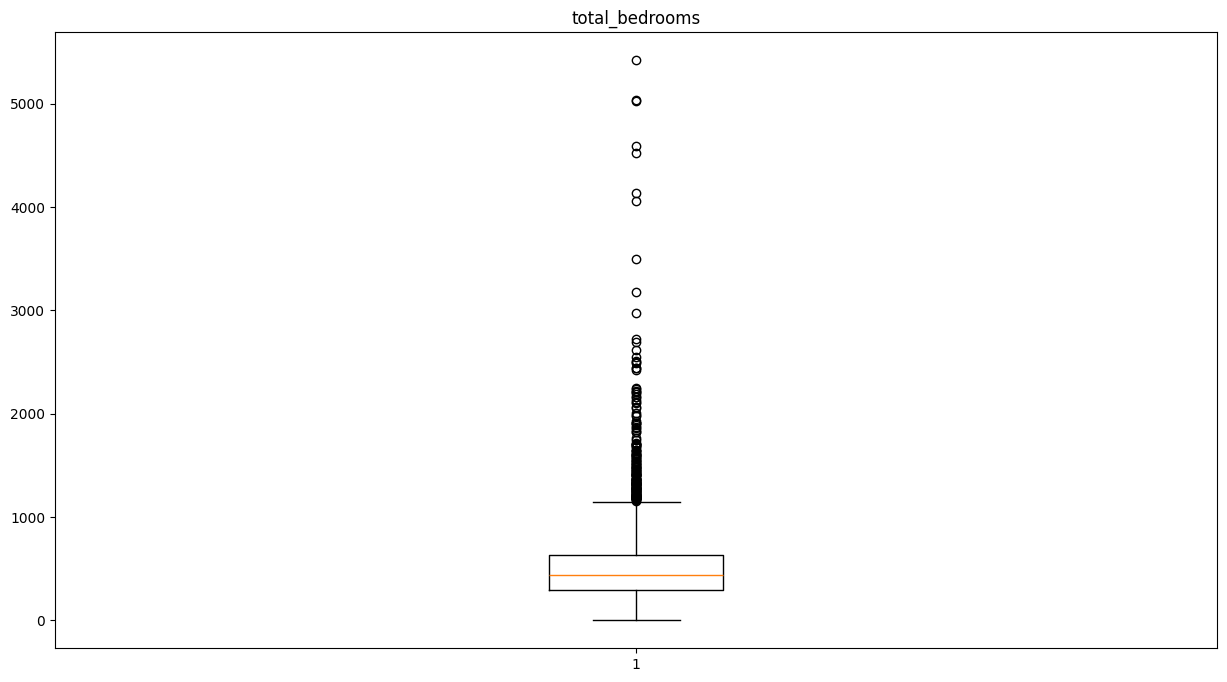

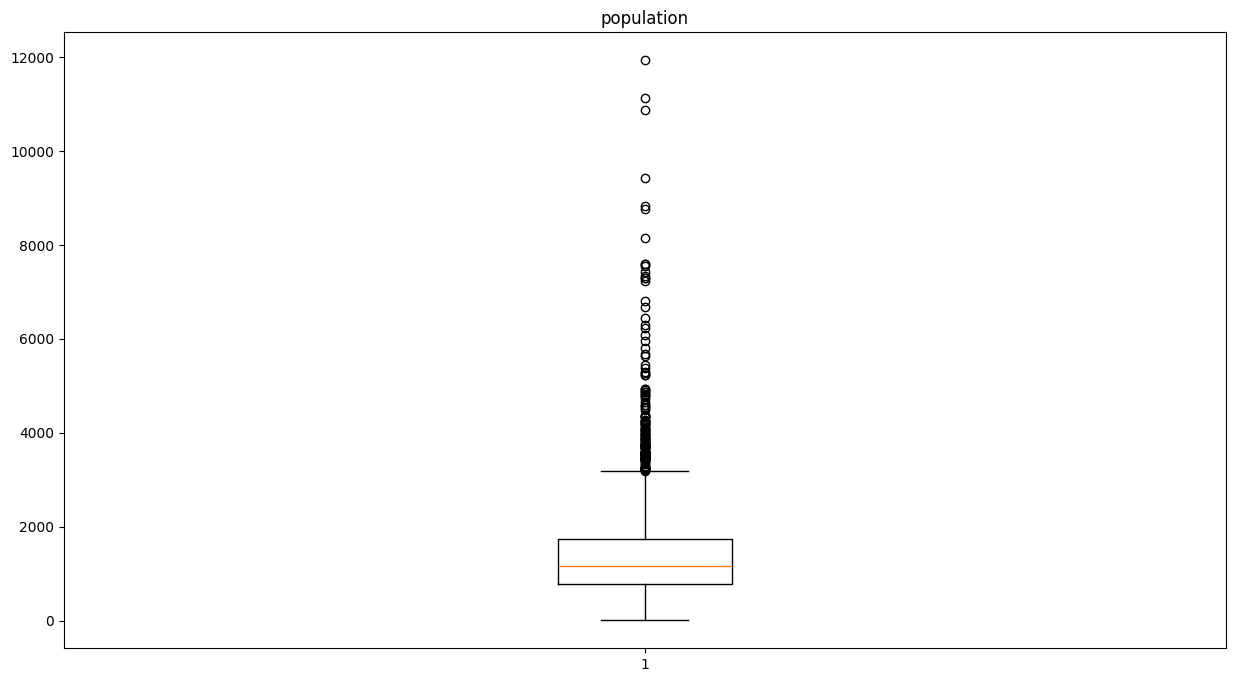

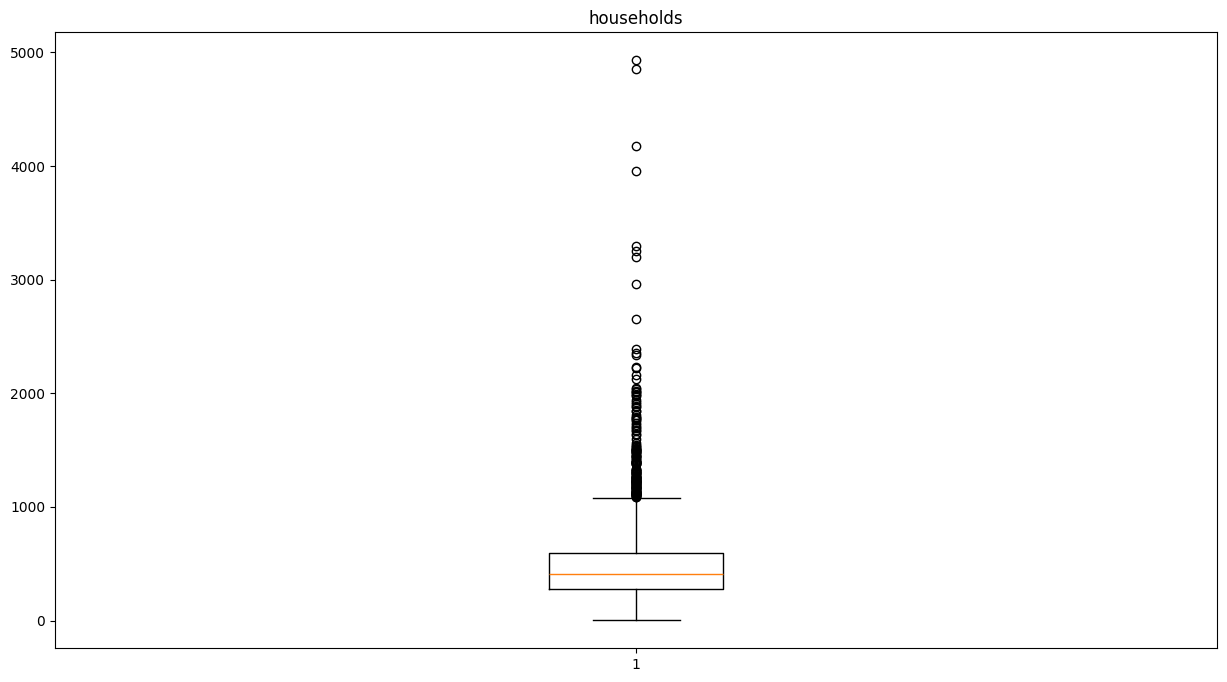

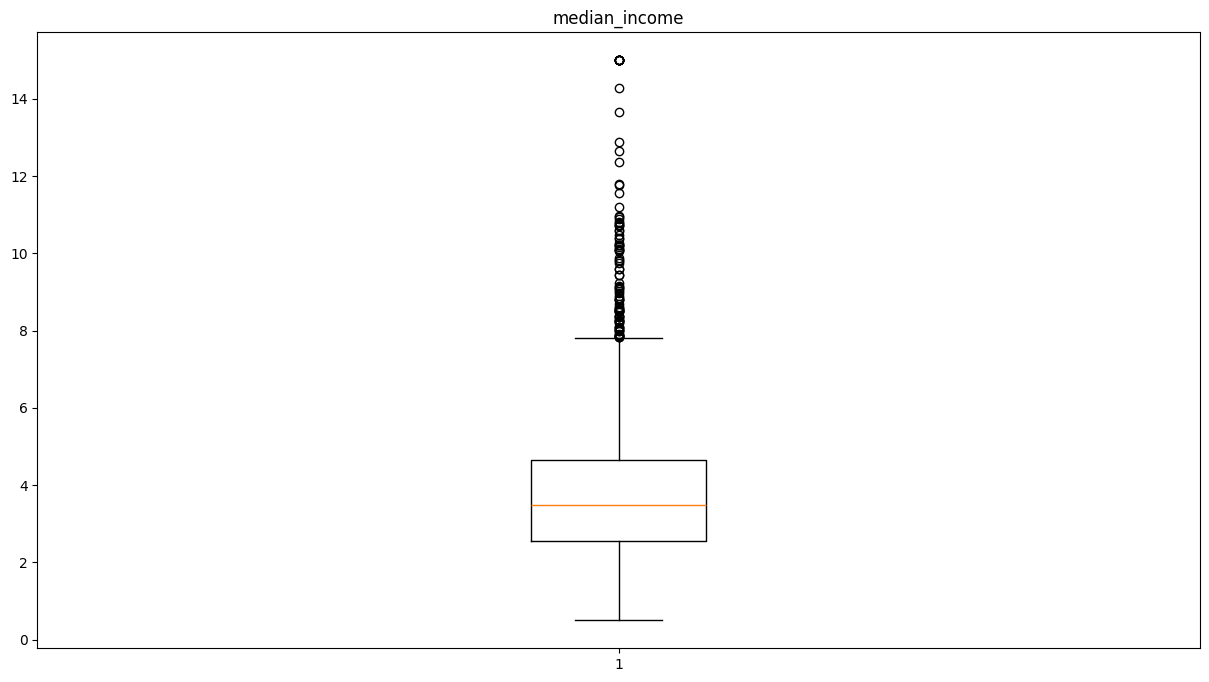

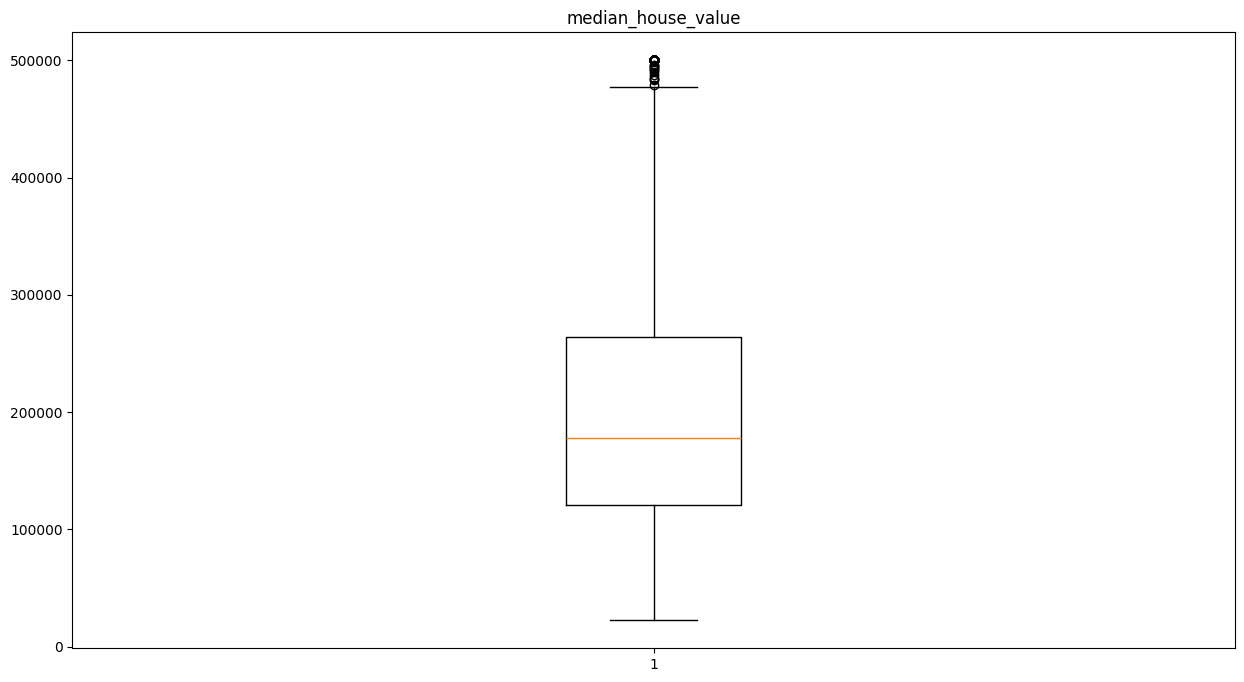

In [8]:
# Checking existance of outliers
for col in df_num.columns:
    plt.figure(figsize=(15, 8))
    plt.boxplot(df_num[col])
    plt.title(col)
    plt.show()

In [9]:
# capping and flooring
for col in df_num.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df_num[col] = df_num[col].clip(lower=lower, upper=upper)

In [10]:
df = pd.concat([df_num, df_cat], axis=1)

In [11]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(3000, 8)
(3000,)


- 2. Training

In [12]:
models = {

    "Linear Regression": LinearRegression(),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ])
}

- 3. Predict and Evaluate

In [13]:
results = []
trained_models = {}

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

    trained_models[name] = model


results_df = pd.DataFrame(results)

print(results_df.sort_values("R2 Score", ascending=False))

                   Model           MSE          RMSE           MAE  R2 Score
1  Polynomial Regression  3.582235e+09  59851.774763  42137.752816  0.703392
2       Ridge Regression  4.183034e+09  64676.376681  48655.474464  0.653646
3       Lasso Regression  4.186337e+09  64701.909307  48682.203416  0.653373
0      Linear Regression  4.186345e+09  64701.970374  48682.277051  0.653372


- 4. Save Best Model

In [14]:
# Best model
results_df = results_df.sort_values("R2 Score", ascending=False)
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best Model:", best_model_name)

Best Model: Polynomial Regression


In [15]:
# Save Best Model
joblib.dump(best_model, "../../models/regression_model.pkl")
print("Model saved successfully")

Model saved successfully
